# Freddie Mac Small Balance Loan Survival Analysis
## Loan-level default and prepayment risk in multifamily RMBS

This end-to-end notebook transforms quarterly Freddie Mac Small Balance Loan
performance data into a competing-risks survival framework and evaluates
loan-level relative default risk.

### Business objective

- Estimate when loans first reach serious credit deterioration.
- Separate default risk from the competing effect of payoff/prepayment.
- Identify interpretable risk factors and rank currently active loans.
- Evaluate whether the limited default history supports reliable prediction.

### Modeling framework

1. Clean and validate the quarterly loan panel.
2. Build start-stop intervals and multi-state transitions.
3. Estimate Kaplan-Meier and Aalen-Johansen curves.
4. Compare LTV, DCR, vintage, and geographic risk groups.
5. Fit a penalized time-varying Cox model.
6. Fit a constrained Random Survival Forest challenger.
7. Evaluate discrimination, calibration, stability, and temporal feasibility.

### Important scope note

The portfolio contains only **51 observed defaults among 14,778 loans**.
Accordingly, predictive outputs are presented as exploratory relative-risk
signals, not production-grade probabilities of default.

### Expected repository layout

```text
project-root/
├── Freddie_Mac_SBL_End_to_End_Survival_Analysis.ipynb
├── data/
│   └── raw/
│       └── Sheet4.xlsx
├── outputs/                 # generated locally; optional in Git
└── analysis_outputs/        # generated locally; optional in Git
```

The loader also supports uploading `Sheet4.xlsx` directly in Google Colab.

## 1. Environment and reproducibility

Install the analysis packages, import the libraries, define reproducible random
seeds, and locate the raw workbook. When running in Colab without the workbook,
an upload prompt appears automatically.

In [ ]:
%pip install -q "numpy<2.4" "pandas<3" openpyxl pyarrow lifelines scikit-survival seaborn shap

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import AalenJohansenFitter, KaplanMeierFitter, CoxTimeVaryingFitter
from lifelines.statistics import multivariate_logrank_test

from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, train_test_split

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score,
)
from sksurv.util import Surv

if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Tied event times were detected.*")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs")
ANALYSIS_OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
ANALYSIS_OUTPUT_DIR.mkdir(exist_ok=True)

DATA_CANDIDATES = [
    Path("data/raw/Sheet4.xlsx"),
    Path("../data/raw/Sheet4.xlsx"),
    Path("Sheet4.xlsx"),
    Path("/content/Sheet4.xlsx"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.is_file()), None)

if DATA_PATH is None:
    try:
        from google.colab import files

        print("Upload Sheet4.xlsx")
        uploaded = files.upload()
        uploaded_workbooks = [
            Path("/content") / name
            for name in uploaded
            if name.lower().endswith(".xlsx")
        ]
        DATA_PATH = uploaded_workbooks[0] if uploaded_workbooks else None
    except ImportError:
        pass

if DATA_PATH is None:
    searched = "\n".join(f"  - {path.resolve()}" for path in DATA_CANDIDATES)
    raise FileNotFoundError(
        "Sheet4.xlsx was not found. Checked:\n" + searched
    )

print(f"Using data file: {DATA_PATH.resolve()}")

Using data file: data/raw/Sheet4.xlsx


## 2. Load the Excel workbook

The workbook has about 202,000 rows, so loading can take 15-30 seconds.

In [2]:
raw = pd.read_excel(DATA_PATH, sheet_name="Sheet4", engine="openpyxl")

# Remove blank Excel columns such as "Unnamed: 26".
raw = raw.loc[:, ~raw.columns.astype(str).str.match(r"^Unnamed")].copy()

print(f"Rows: {len(raw):,}")
print(f"Columns: {raw.shape[1]}")
display(raw.head())

Rows: 202,285
Columns: 26


,lnno,quarter,mrtg_status,amt_upb_endg,liq_upb_amt,dt_fund,amt_upb_pch,dealname,rate_ltv,rate_dcr,code_int,rate_int,cd_fxfltr,cnt_amtn_per,cnt_blln_term,cnt_io_per,cnt_mrtg_term,cnt_rsdntl_unit,cnt_yld_maint,code_sr,dt_io_end,dt_mty,geographical_region,code_st,securitized,Status Category
0,406932499,y17q4,100,"1,298,176.0000",NaN,2017-10-25,"1,300,000.0000",SB-44,0.6753,1.3152,FIX,0.0415,NaN,360.0000,120.0000,0.0000,120,15.0000,84.0000,NaN,NaT,2027-11-01,MINNEAPOLIS-ST. PAUL,MN,YES,Current
1,406932499,y18q1,100,"1,292,670.1800",NaN,2017-10-25,"1,300,000.0000",SB-44,0.6753,1.3152,FIX,0.0415,NaN,360.0000,120.0000,0.0000,120,15.0000,84.0000,NaN,NaT,2027-11-01,MINNEAPOLIS-ST. PAUL,MN,YES,Current
2,406932499,y18q2,100,"1,287,403.0700",NaN,2017-10-25,"1,300,000.0000",SB-44,0.6753,1.3152,FIX,0.0415,NaN,360.0000,120.0000,0.0000,120,15.0000,84.0000,NaN,NaT,2027-11-01,MINNEAPOLIS-ST. PAUL,MN,YES,Current
3,406932499,y18q3,100,"1,282,079.1700",NaN,2017-10-25,"1,300,000.0000",SB-44,0.6753,1.3152,FIX,0.0415,NaN,360.0000,120.0000,0.0000,120,15.0000,84.0000,NaN,NaT,2027-11-01,MINNEAPOLIS-ST. PAUL,MN,YES,Current
4,406932499,y18q4,100,"1,276,551.2200",NaN,2017-10-25,"1,300,000.0000",SB-44,0.6753,1.3152,FIX,0.0415,NaN,360.0000,120.0000,0.0000,120,15.0000,84.0000,NaN,NaT,2027-11-01,MINNEAPOLIS-ST. PAUL,MN,YES,Current


## 3. Standardize the schema and data types

In [3]:
def to_snake_case(columns):
    return (
        pd.Index(columns)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )


df = raw.copy()
df.columns = to_snake_case(df.columns)

required_columns = {
    "lnno", "quarter", "mrtg_status", "dt_fund", "dt_mty",
    "amt_upb_pch", "amt_upb_endg", "liq_upb_amt", "dealname",
    "rate_ltv", "rate_dcr", "rate_int", "code_st"
}
missing_required = required_columns.difference(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {sorted(missing_required)}")

numeric_columns = [
    "amt_upb_endg", "liq_upb_amt", "amt_upb_pch", "rate_ltv",
    "rate_dcr", "rate_int", "cnt_amtn_per", "cnt_blln_term",
    "cnt_io_per", "cnt_mrtg_term", "cnt_rsdntl_unit", "cnt_yld_maint"
]
date_columns = ["dt_fund", "dt_io_end", "dt_mty"]
categorical_columns = [
    "dealname", "code_int", "cd_fxfltr", "code_sr",
    "geographical_region", "code_st", "securitized"
]

for column in numeric_columns:
    if column in df:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in date_columns:
    if column in df:
        df[column] = pd.to_datetime(df[column], errors="coerce")

df["loan_id"] = df["lnno"].astype("string")
df["status_code"] = pd.to_numeric(df["mrtg_status"], errors="coerce").astype("Int64")
df["original_status_category"] = df["status_category"].astype("string")

for column in categorical_columns:
    if column in df:
        df[column] = df[column].astype("string").str.strip()

## 4. Correct and document loan-status definitions

Model definitions used here:

- **Delinquency:** first occurrence of 30+ days delinquent.
- **Serious delinquency:** first occurrence of 60+ days delinquent.
- **Default:** first occurrence of 90+ days delinquent or foreclosure.
- **Competing event:** paid off/liquidated before default.

Keep the raw status columns so the correction remains fully traceable.

In [4]:
STATUS_MAP = {
    100: "Current",
    200: "30 Days",
    250: "60 Days",
    300: "90+ Days",
    450: "Foreclosure",
    500: "Paid Off",
}

unknown_statuses = sorted(
    set(df["status_code"].dropna().astype(int)).difference(STATUS_MAP)
)
if unknown_statuses:
    raise ValueError(f"Unmapped mortgage status codes: {unknown_statuses}")

df["loan_state"] = df["status_code"].map(STATUS_MAP).astype("string")
df["is_30_plus"] = df["status_code"].isin([200, 250, 300, 450]).astype("int8")
df["is_60_plus"] = df["status_code"].isin([250, 300, 450]).astype("int8")
df["is_default_state"] = df["status_code"].isin([300, 450]).astype("int8")
df["is_paid_off"] = df["status_code"].eq(500).astype("int8")

status_audit = (
    df.groupby(["status_code", "original_status_category", "loan_state"], dropna=False)
      .agg(rows=("loan_id", "size"), loans=("loan_id", "nunique"),
           liquidation_upb_present=("liq_upb_amt", "count"))
      .reset_index()
)
display(status_audit)

,status_code,original_status_category,loan_state,rows,loans,liquidation_upb_present
0,100,Current,Current,195429,14777,0
1,200,30 Days,30 Days,1278,360,0
2,250,60 Days,60 Days,18,18,18
3,300,90+ Days,90+ Days,150,39,0
4,450,Foreclosure,Foreclosure,27,18,15
5,500,REO,Paid Off,5383,5251,4604


## 5. Repair century-shifted dates and parse reporting quarters

Many maturity and interest-only dates were stored in the 1930s even though
the corresponding loans were funded after 2014. Values before 2000 are moved
forward exactly 100 years, and flags retain an audit trail.

In [5]:
def repair_century_shift(series, flag_name):
    series = pd.to_datetime(series, errors="coerce")
    shifted = series.notna() & series.dt.year.lt(2000)
    df[flag_name] = shifted.astype("int8")
    return series.mask(shifted, series + pd.DateOffset(years=100))


df["dt_mty"] = repair_century_shift(df["dt_mty"], "maturity_date_repaired")
df["dt_io_end"] = repair_century_shift(df["dt_io_end"], "io_end_date_repaired")

quarter_parts = df["quarter"].astype("string").str.lower().str.extract(
    r"^y(?P<yy>\d{2})q(?P<q>[1-4])$"
)
if quarter_parts.isna().any(axis=None):
    bad_quarters = df.loc[quarter_parts.isna().any(axis=1), "quarter"].unique()
    raise ValueError(f"Unrecognized quarter labels: {bad_quarters[:10]}")

df["report_year"] = 2000 + quarter_parts["yy"].astype(int)
df["report_quarter"] = quarter_parts["q"].astype(int)
df["report_period"] = pd.PeriodIndex(
    df["report_year"].astype(str) + "Q" + df["report_quarter"].astype(str),
    freq="Q",
)
df["report_date"] = df["report_period"].dt.to_timestamp(how="end").dt.normalize()

# Integer quarter clocks create the start-stop intervals used by CoxTimeVaryingFitter.
df["report_q_index"] = df["report_year"] * 4 + df["report_quarter"]
df["fund_q_index"] = df["dt_fund"].dt.year * 4 + df["dt_fund"].dt.quarter
df["t_start"] = (df["report_q_index"] - df["fund_q_index"]).astype("int32")
df["t_stop"] = (df["t_start"] + 1).astype("int32")

if df["t_start"].lt(0).any():
    raise ValueError("At least one reporting quarter occurs before its funding quarter.")

## 6. Validate the panel structure

In [6]:
df = df.sort_values(["loan_id", "report_q_index"]).reset_index(drop=True)

duplicate_keys = df.duplicated(["loan_id", "report_period"], keep=False)
if duplicate_keys.any():
    raise ValueError(
        f"Found {duplicate_keys.sum():,} rows with duplicate loan-quarter keys."
    )

df["quarter_gap"] = df.groupby("loan_id")["report_q_index"].diff()
gap_rows = df["quarter_gap"].gt(1).sum()

quality_report = pd.Series({
    "rows": len(df),
    "unique_loans": df["loan_id"].nunique(),
    "unique_deals": df["dealname"].nunique(),
    "duplicate_loan_quarters": int(duplicate_keys.sum()),
    "nonconsecutive_quarter_rows": int(gap_rows),
    "maturity_dates_repaired": int(df["maturity_date_repaired"].sum()),
    "io_end_dates_repaired": int(df["io_end_date_repaired"].sum()),
    "missing_ending_upb": int(df["amt_upb_endg"].isna().sum()),
    "negative_ending_upb": int(df["amt_upb_endg"].lt(0).sum()),
})
display(quality_report.to_frame("value"))

# Tiny negative balances are accounting residuals; set them to zero and flag them.
df["ending_upb_negative_repaired"] = df["amt_upb_endg"].lt(0).astype("int8")
df["amt_upb_endg"] = df["amt_upb_endg"].clip(lower=0)

,value
rows,202285
unique_loans,14778
unique_deals,104
duplicate_loan_quarters,0
nonconsecutive_quarter_rows,133
maturity_dates_repaired,119278
io_end_dates_repaired,1022
missing_ending_upb,2104
negative_ending_upb,1


## 7. Engineer time-varying and lagged features

Current-quarter status and liquidation UPB must not be used to predict the
same-quarter event. We therefore create lagged status features and explicitly
exclude event-revealing fields from the future modeling matrix.

In [7]:
loan_group = df.groupby("loan_id", sort=False)

df["loan_age_quarters"] = df["t_stop"]
df["loan_age_months"] = df["loan_age_quarters"] * 3
df["remaining_term_months"] = (
    (df["dt_mty"] - df["report_date"]).dt.days / 30.4375
).clip(lower=0)
df["upb_ratio"] = df["amt_upb_endg"] / df["amt_upb_pch"].replace(0, np.nan)
df["upb_change_pct"] = loan_group["amt_upb_endg"].pct_change(fill_method=None)

df["prior_loan_state"] = loan_group["loan_state"].shift(1).fillna("Current")
df["prior_30_plus"] = df["prior_loan_state"].isin(
    ["30 Days", "60 Days", "90+ Days", "Foreclosure"]
).astype("int8")
df["prior_60_plus"] = df["prior_loan_state"].isin(
    ["60 Days", "90+ Days", "Foreclosure"]
).astype("int8")

# Consecutive prior delinquent quarters, excluding the current outcome quarter.
def previous_streak(values):
    result = []
    streak = 0
    for value in values:
        result.append(streak)
        streak = streak + 1 if value else 0
    return pd.Series(result, index=values.index, dtype="int16")


df["prior_delinquency_streak"] = (
    df.groupby("loan_id", group_keys=False)["is_30_plus"].apply(previous_streak)
)

## 8. Create the multi-state transition table

In [8]:
df["state_from"] = loan_group["loan_state"].shift(1).fillna("Entry")
df["state_to"] = df["loan_state"]
df["state_changed"] = df["state_from"].ne(df["state_to"]).astype("int8")
df["transition"] = df["state_from"] + " -> " + df["state_to"]

transition_summary = (
    df.loc[df["state_changed"].eq(1), "transition"]
      .value_counts()
      .rename_axis("transition")
      .reset_index(name="count")
)
display(transition_summary.head(20))

loan_panel_clean = df.copy()

,transition,count
0,Entry -> Current,14777
1,Current -> Paid Off,5175
2,Current -> 30 Days,385
3,30 Days -> Current,183
4,30 Days -> Paid Off,63
5,30 Days -> 90+ Days,37
6,90+ Days -> Paid Off,12
7,30 Days -> Foreclosure,12
8,30 Days -> 60 Days,10
9,90+ Days -> Foreclosure,6


## 9. Create the competing-risks start-stop survival table

Event codes:

- `0`: still active/censored
- `1`: default (first 90+ delinquency or foreclosure)
- `2`: paid off before default

Each loan is retained only through its first terminal event. For a
cause-specific default Cox model, use `default_event` as the event column;
payoff rows remain in the table but are censored at payoff.

In [9]:
df["terminal_now"] = (
    df["is_default_state"].eq(1) | df["is_paid_off"].eq(1)
).astype("int8")

df["terminal_seen_before"] = (
    df.groupby("loan_id")["terminal_now"].cumsum() - df["terminal_now"]
)
survival_time_varying = df.loc[df["terminal_seen_before"].eq(0)].copy()

survival_time_varying["event_type"] = np.select(
    [
        survival_time_varying["is_default_state"].eq(1),
        survival_time_varying["is_paid_off"].eq(1),
    ],
    [1, 2],
    default=0,
).astype("int8")
survival_time_varying["default_event"] = (
    survival_time_varying["event_type"].eq(1)
).astype("int8")
survival_time_varying["prepay_event"] = (
    survival_time_varying["event_type"].eq(2)
).astype("int8")

loan_outcomes = (
    survival_time_varying.groupby("loan_id", as_index=False)
    .agg(
        first_fund_date=("dt_fund", "first"),
        last_report_date=("report_date", "max"),
        duration_quarters=("t_stop", "max"),
        default_event=("default_event", "max"),
        prepay_event=("prepay_event", "max"),
        dealname=("dealname", "first"),
    )
)
loan_outcomes["event_type"] = np.select(
    [loan_outcomes["default_event"].eq(1), loan_outcomes["prepay_event"].eq(1)],
    ["Default", "Paid Off"],
    default="Censored",
)

display(loan_outcomes["event_type"].value_counts().to_frame("loans"))

,loans
event_type,
Censored,9489
Paid Off,5238
Default,51


## 10. Define modeling-safe columns

Numeric imputation and categorical encoding should be fitted **inside each
training fold later**, not on the entire dataset. This prevents validation
leakage. The following list deliberately excludes outcome-revealing fields.

In [10]:
STATIC_FEATURES = [
    "rate_ltv", "rate_dcr", "rate_int", "amt_upb_pch",
    "cnt_amtn_per", "cnt_blln_term", "cnt_io_per", "cnt_mrtg_term",
    "cnt_rsdntl_unit", "cnt_yld_maint", "code_int", "cd_fxfltr",
    "geographical_region", "code_st", "securitized", "dealname",
]

TIME_VARYING_FEATURES = [
    "amt_upb_endg", "upb_ratio", "upb_change_pct", "loan_age_quarters",
    "remaining_term_months", "prior_30_plus", "prior_60_plus",
    "prior_delinquency_streak",
]

LEAKAGE_EXCLUSIONS = [
    "liq_upb_amt", "mrtg_status", "status_code", "status_category",
    "original_status_category", "loan_state", "is_default_state",
    "is_paid_off", "terminal_now", "event_type",
]

MODEL_FEATURES = [
    c for c in STATIC_FEATURES + TIME_VARYING_FEATURES
    if c in survival_time_varying.columns
]

print(f"Candidate model features: {len(MODEL_FEATURES)}")
print(MODEL_FEATURES)

Candidate model features: 24
['rate_ltv', 'rate_dcr', 'rate_int', 'amt_upb_pch', 'cnt_amtn_per', 'cnt_blln_term', 'cnt_io_per', 'cnt_mrtg_term', 'cnt_rsdntl_unit', 'cnt_yld_maint', 'code_int', 'cd_fxfltr', 'geographical_region', 'code_st', 'securitized', 'dealname', 'amt_upb_endg', 'upb_ratio', 'upb_change_pct', 'loan_age_quarters', 'remaining_term_months', 'prior_30_plus', 'prior_60_plus', 'prior_delinquency_streak']


## 11. Final checks

In [11]:
assert not loan_panel_clean.duplicated(["loan_id", "report_period"]).any()
assert survival_time_varying["t_stop"].gt(survival_time_varying["t_start"]).all()
assert survival_time_varying.groupby("loan_id")["default_event"].sum().le(1).all()
assert survival_time_varying.groupby("loan_id")["prepay_event"].sum().le(1).all()
assert not survival_time_varying[["loan_id", "t_start", "t_stop"]].isna().any().any()

print("Preprocessing completed successfully.")
print(f"Clean panel: {loan_panel_clean.shape}")
print(f"Time-varying survival table: {survival_time_varying.shape}")
print(f"Loan-level outcomes: {loan_outcomes.shape}")

Preprocessing completed successfully.
Clean panel: (202285, 59)
Time-varying survival table: (201995, 64)
Loan-level outcomes: (14778, 8)


---

# Part II - Survival analysis and predictive modeling

The preprocessing stage has produced both the complete multi-state panel and a
start-stop table ending at the first default or payoff. The remaining sections
estimate portfolio survival, compare risk groups, fit constrained models, and
test how far the results can be generalized.

## Analysis-ready loan-level table and event diagnostics

Baseline characteristics are taken from the first observed quarter. This table
is used for nonparametric curves, subgroup analysis, and the baseline RSF.

In [12]:
baseline_columns = [
    "loan_id", "dt_fund", "rate_ltv", "rate_dcr", "rate_int",
    "amt_upb_pch", "cnt_mrtg_term", "cnt_rsdntl_unit", "cnt_io_per",
    "cnt_yld_maint", "code_st", "dealname", "geographical_region",
]
baseline_columns = [c for c in baseline_columns if c in survival_time_varying.columns]

baseline = (
    survival_time_varying
    .sort_values(["loan_id", "t_start"])
    .drop_duplicates("loan_id", keep="first")[baseline_columns]
)

analysis = loan_outcomes.merge(baseline, on="loan_id", how="left", validate="one_to_one")
analysis["default_event"] = analysis["default_event"].astype(bool)
analysis["prepay_event"] = analysis["prepay_event"].astype(bool)
analysis["event_code"] = np.select(
    [analysis["default_event"], analysis["prepay_event"]],
    [1, 2],
    default=0,
).astype("int8")

event_diagnostics = pd.DataFrame({
    "loan_count": [len(analysis)],
    "defaults": [int(analysis["default_event"].sum())],
    "paid_off": [int(analysis["prepay_event"].sum())],
    "censored": [int((analysis["event_code"] == 0).sum())],
    "default_pct": [100 * analysis["default_event"].mean()],
    "median_followup_quarters": [analysis["duration_quarters"].median()],
})
display(event_diagnostics)

if analysis["default_event"].sum() < 100:
    print(
        "RARE-EVENT WARNING: fewer than 100 defaults. Keep Cox predictors limited, "
        "regularize models, and treat subgroup and ML results as exploratory."
    )

RARE-EVENT WARNING: fewer than 100 defaults. Keep Cox predictors limited, regularize models, and treat subgroup and ML results as exploratory.


,loan_count,defaults,paid_off,censored,default_pct,median_followup_quarters
0,14778,51,5238,9489,0.3451,15.0000


## Stage 1 - Overall Kaplan-Meier curve

This estimates **cause-specific default-free survival**. Paid-off loans are
censored. Because payoff prevents later default, `1 - KM` can overstate the
absolute probability of default; use Aalen-Johansen in Stage 2 for that.

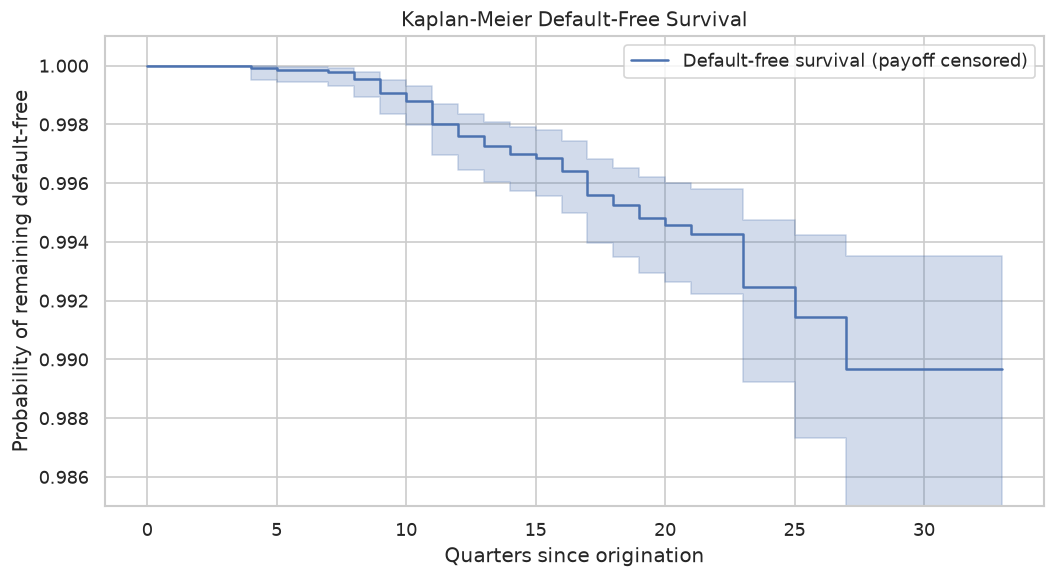

,quarter,default_free_survival,one_minus_km
0,4,0.9999,0.0001
1,8,0.9995,0.0005
2,12,0.9976,0.0024
3,16,0.9964,0.0036
4,20,0.9946,0.0054
5,24,0.9925,0.0075
6,28,0.9897,0.0103
7,32,0.9897,0.0103


In [13]:
km_default = KaplanMeierFitter(label="Default-free survival (payoff censored)")
km_default.fit(
    durations=analysis["duration_quarters"],
    event_observed=analysis["default_event"],
)

fig, ax = plt.subplots(figsize=(9, 5))
km_default.plot_survival_function(ax=ax, ci_show=True)
ax.set(
    title="Kaplan-Meier Default-Free Survival",
    xlabel="Quarters since origination",
    ylabel="Probability of remaining default-free",
    ylim=(0.985, 1.001),
)
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / "01_kaplan_meier_default_free.png", dpi=160)
plt.show()

km_horizons = pd.DataFrame({
    "quarter": [4, 8, 12, 16, 20, 24, 28, 32],
})
km_horizons["default_free_survival"] = km_default.predict(km_horizons["quarter"]).values
km_horizons["one_minus_km"] = 1 - km_horizons["default_free_survival"]
display(km_horizons)

## Stage 2 - Aalen-Johansen competing-risk cumulative incidence

Event codes are `0 = censored`, `1 = default`, and `2 = paid off`. These are
the primary portfolio-level curves because they recognize that payoff removes
a loan from future default risk.

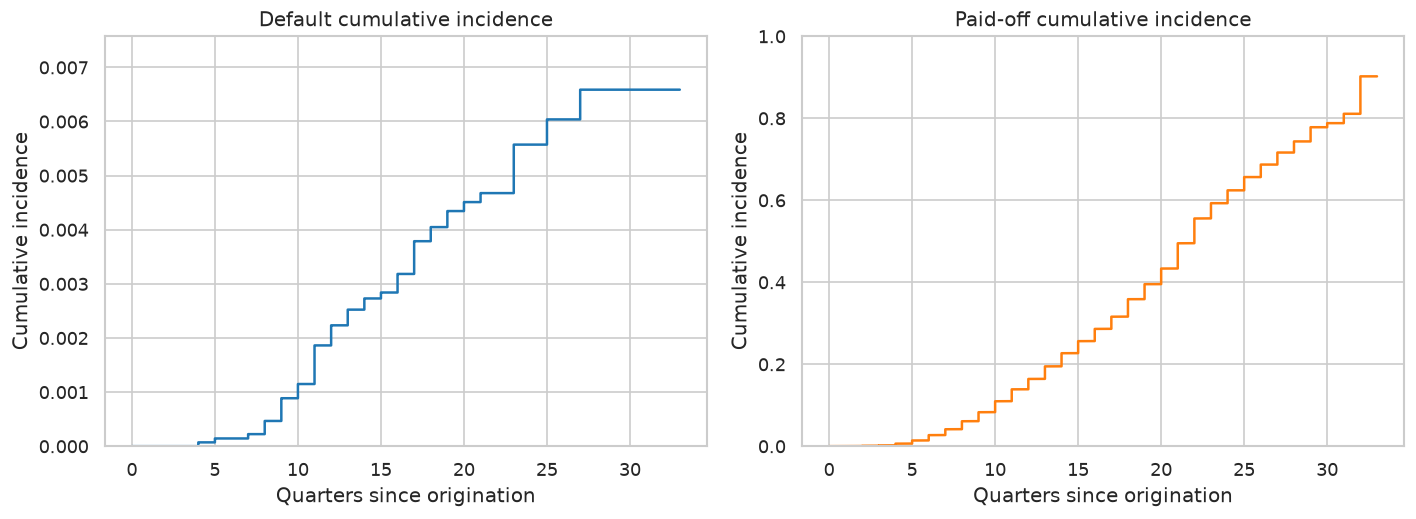

,quarter,default_cif,paid_off_cif
0,4,0.0001,0.0042
1,8,0.0004,0.0505
2,12,0.0020,0.1504
3,16,0.0029,0.2709
4,20,0.0043,0.4133
5,24,0.0056,0.6056
6,28,0.0066,0.7297
7,32,0.0066,0.8107


In [14]:
aj_default = AalenJohansenFitter(calculate_variance=True, seed=RANDOM_STATE)
aj_prepay = AalenJohansenFitter(calculate_variance=True, seed=RANDOM_STATE)

aj_default.fit(
    durations=analysis["duration_quarters"],
    event_observed=analysis["event_code"],
    event_of_interest=1,
    label="Default CIF",
)
aj_prepay.fit(
    durations=analysis["duration_quarters"],
    event_observed=analysis["event_code"],
    event_of_interest=2,
    label="Paid-off CIF",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
default_cif = aj_default.cumulative_density_.iloc[:, 0]
prepay_cif = aj_prepay.cumulative_density_.iloc[:, 0]
axes[0].step(default_cif.index, default_cif.values, where="post", color="tab:blue")
axes[0].set(
    title="Default cumulative incidence",
    xlabel="Quarters since origination",
    ylabel="Cumulative incidence",
    ylim=(0, max(default_cif.max() * 1.15, 0.001)),
)
axes[1].step(prepay_cif.index, prepay_cif.values, where="post", color="tab:orange")
axes[1].set(
    title="Paid-off cumulative incidence",
    xlabel="Quarters since origination",
    ylabel="Cumulative incidence",
    ylim=(0, 1),
)
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / "02_competing_risk_cif.png", dpi=160)
plt.show()


def step_value_at(series, time):
    eligible = series.index[series.index <= time]
    return float(series.loc[eligible[-1]]) if len(eligible) else 0.0


cif_horizons = pd.DataFrame({"quarter": [4, 8, 12, 16, 20, 24, 28, 32]})
cif_horizons["default_cif"] = [step_value_at(default_cif, t) for t in cif_horizons["quarter"]]
cif_horizons["paid_off_cif"] = [step_value_at(prepay_cif, t) for t in cif_horizons["quarter"]]
display(cif_horizons)

## Stage 3 - Define interpretable risk groups

Cutoffs are fixed before inspecting group outcomes. Avoid data-driven cutoffs
optimized on only 51 defaults.

In [15]:
analysis["ltv_group"] = pd.cut(
    analysis["rate_ltv"],
    bins=[-np.inf, 0.60, 0.70, 0.75, np.inf],
    labels=["<=60%", "60-70%", "70-75%", ">75%"],
)
analysis["dcr_group"] = pd.cut(
    analysis["rate_dcr"],
    bins=[-np.inf, 1.25, 1.50, 2.00, np.inf],
    labels=["<=1.25x", "1.25-1.50x", "1.50-2.00x", ">2.00x"],
)
analysis["vintage_year"] = pd.to_datetime(analysis["dt_fund"]).dt.year
analysis["vintage_group"] = pd.cut(
    analysis["vintage_year"],
    bins=[2013, 2016, 2018, 2020, 2022],
    labels=["2014-2016", "2017-2018", "2019-2020", "2021-2022"],
)

REGION_STATES = {
    "Northeast": set("CT ME MA NH RI VT NJ NY PA".split()),
    "Midwest": set("IN IL MI OH WI IA KS MN MO NE ND SD".split()),
    "South": set("DE FL GA MD NC SC VA DC WV AL KY MS TN AR LA OK TX".split()),
    "West": set("AZ CO ID MT NV NM UT WY AK CA HI OR WA".split()),
}
STATE_TO_REGION = {
    state: region
    for region, states in REGION_STATES.items()
    for state in states
}
analysis["census_region"] = analysis["code_st"].map(STATE_TO_REGION).fillna("Other/Unknown")


def group_event_summary(data, group_col):
    result = (
        data.groupby(group_col, observed=True, dropna=False)
        .agg(
            loans=("loan_id", "nunique"),
            defaults=("default_event", "sum"),
            paid_off=("prepay_event", "sum"),
            median_followup=("duration_quarters", "median"),
        )
        .reset_index()
    )
    result["defaults_per_1000"] = 1000 * result["defaults"] / result["loans"]
    return result


for group_column in ["ltv_group", "dcr_group", "vintage_group", "census_region"]:
    print(f"\n{group_column}")
    display(group_event_summary(analysis, group_column))


ltv_group

dcr_group

vintage_group

census_region


,ltv_group,loans,defaults,paid_off,median_followup,defaults_per_1000
0,<=60%,3001,1,815,14.0000,0.3332
1,60-70%,4533,14,1466,14.0000,3.0885
2,70-75%,3336,14,1222,13.0000,4.1966
3,>75%,3908,22,1735,16.0000,5.6295


,dcr_group,loans,defaults,paid_off,median_followup,defaults_per_1000
0,<=1.25x,1451,18,376,17.0000,12.4052
1,1.25-1.50x,3095,10,867,13.0000,3.2310
2,1.50-2.00x,7517,18,3178,15.0000,2.3946
3,>2.00x,2715,5,817,10.0000,1.8416


,vintage_group,loans,defaults,paid_off,median_followup,defaults_per_1000
0,2014-2016,2623,10,1858,21.0000,3.8124
1,2017-2018,5419,32,2472,19.0000,5.9051
2,2019-2020,3738,9,831,13.0000,2.4077
3,2021-2022,2998,0,77,6.0000,0.0000


,census_region,loans,defaults,paid_off,median_followup,defaults_per_1000
0,Midwest,2465,11,642,16.0000,4.4625
1,Northeast,4006,27,1356,17.0000,6.7399
2,South,3851,12,1592,13.0000,3.1161
3,West,4456,1,1648,13.0000,0.2244


## Stage 4 - Subgroup cumulative-incidence curves

Curves with fewer than three default events are omitted, and each displayed
curve stops once fewer than 10% of the original group (or fewer than 100
loans) remain under observation. These are display safeguards, not claims of
statistical sufficiency.

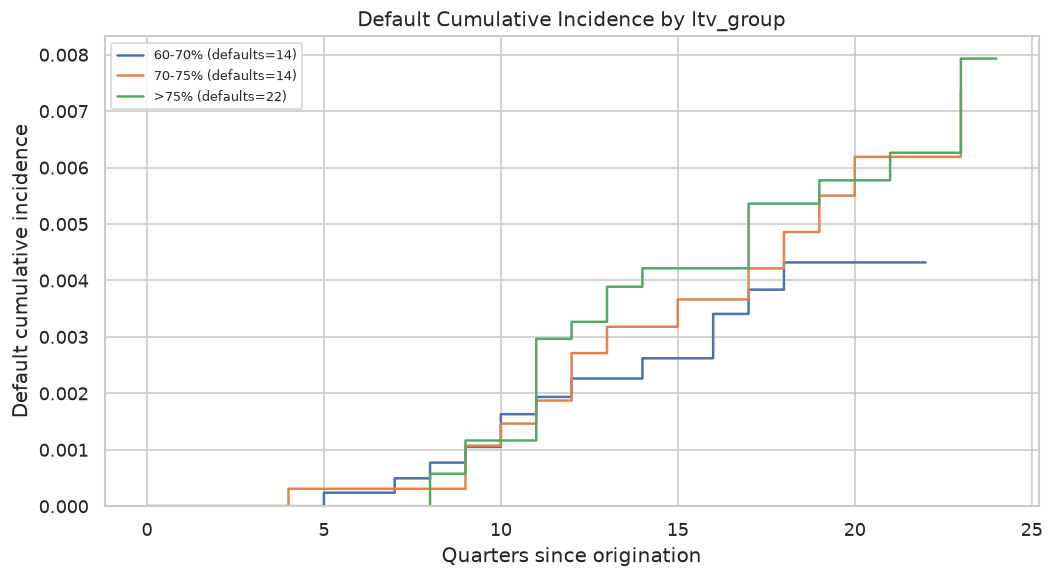

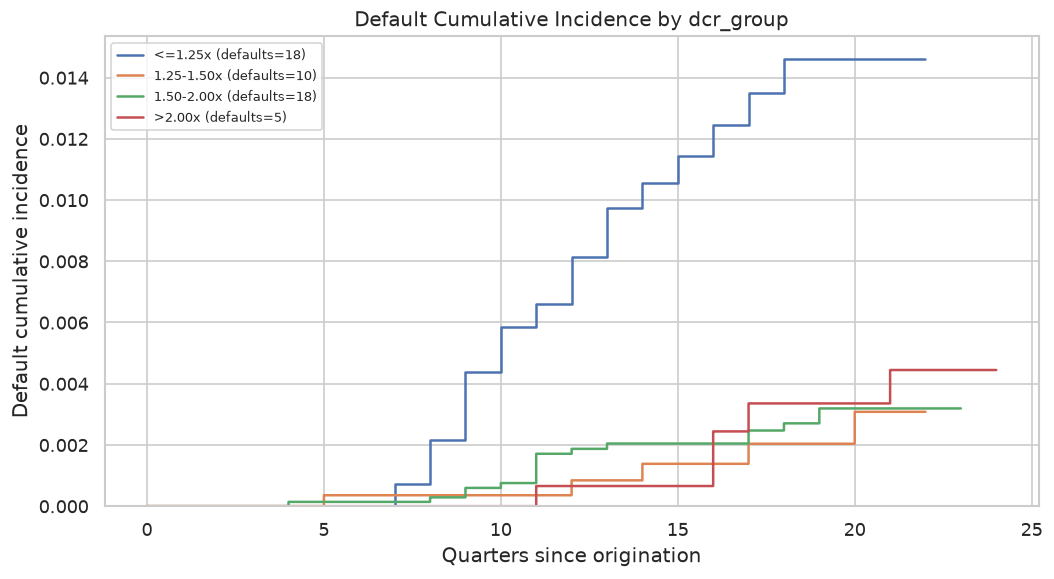

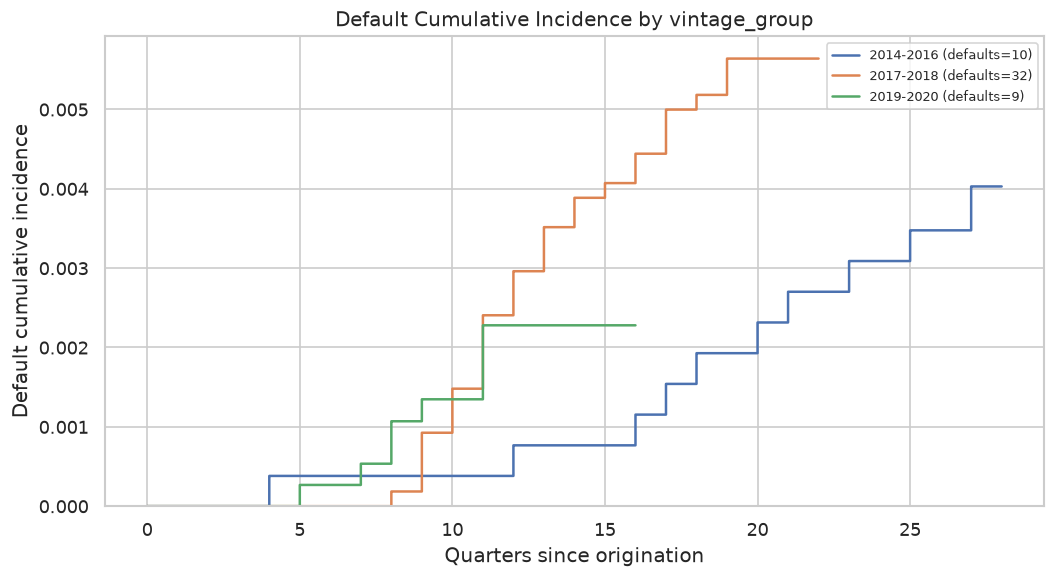

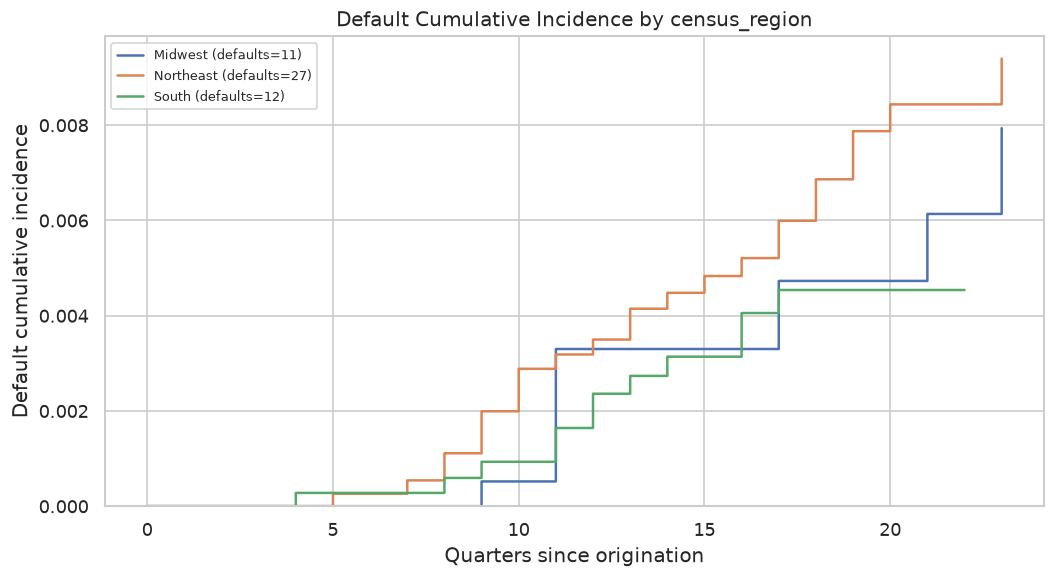

In [16]:
def plot_default_cif_by_group(data, group_col, min_defaults=3):
    fig, ax = plt.subplots(figsize=(9, 5))
    plotted = []

    for group_name, subset in data.groupby(group_col, observed=True, dropna=False):
        defaults = int(subset["default_event"].sum())
        if defaults < min_defaults:
            continue

        fitter = AalenJohansenFitter(
            calculate_variance=False,
            seed=RANDOM_STATE,
        )
        fitter.fit(
            durations=subset["duration_quarters"],
            event_observed=subset["event_code"],
            event_of_interest=1,
        )
        curve = fitter.cumulative_density_.iloc[:, 0]
        min_at_risk = max(100, int(np.ceil(0.10 * len(subset))))
        reliable_times = [
            time
            for time in sorted(subset["duration_quarters"].unique())
            if subset["duration_quarters"].ge(time).sum() >= min_at_risk
        ]
        if reliable_times:
            curve = curve.loc[curve.index <= max(reliable_times) + 1e-6]
        label = f"{group_name} (defaults={defaults})"
        ax.step(curve.index, curve.values, where="post", label=label)
        plotted.append(str(group_name))

    if not plotted:
        plt.close(fig)
        print(f"No {group_col} categories had at least {min_defaults} defaults.")
        return

    ax.set(
        title=f"Default Cumulative Incidence by {group_col}",
        xlabel="Quarters since origination",
        ylabel="Default cumulative incidence",
    )
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    plt.tight_layout()
    filename = f"03_cif_by_{group_col}.png"
    plt.savefig(ANALYSIS_OUTPUT_DIR / filename, dpi=160)
    plt.show()


for group_column in ["ltv_group", "dcr_group", "vintage_group", "census_region"]:
    plot_default_cif_by_group(analysis, group_column)

## Stage 5 - Exploratory cause-specific log-rank tests

These tests treat paid-off loans as censored. They test equality of
cause-specific default hazards, not equality of competing-risk CIFs. With only
51 defaults, focus on effect direction and uncertainty rather than p-value
thresholds.

In [17]:
logrank_results = []

for group_column in ["ltv_group", "dcr_group", "vintage_group", "census_region"]:
    test_data = analysis.dropna(subset=[group_column]).copy()
    result = multivariate_logrank_test(
        event_durations=test_data["duration_quarters"],
        groups=test_data[group_column].astype(str),
        event_observed=test_data["default_event"],
    )
    logrank_results.append({
        "group": group_column,
        "test_statistic": result.test_statistic,
        "p_value": result.p_value,
        "defaults": int(test_data["default_event"].sum()),
    })

logrank_results = pd.DataFrame(logrank_results)
display(logrank_results)

,group,test_statistic,p_value,defaults
0,ltv_group,12.4997,0.0059,51
1,dcr_group,28.8484,0.0000,51
2,vintage_group,5.1224,0.1630,51
3,census_region,21.3570,0.0001,51


## Stage 6 - Penalized time-varying Cox model

Four predictors are used because there are only 51 events. LTV, DCR, and UPB
ratio are rescaled so hazard ratios correspond to meaningful increments.
Current-quarter outcome fields and liquidation UPB are excluded.

In [18]:
tv = survival_time_varying.copy()

tv["ltv_per_10pp"] = tv["rate_ltv"] / 0.10
tv["dcr_per_0_25x"] = tv["rate_dcr"] / 0.25
tv["upb_ratio_per_10pp"] = tv["upb_ratio"] / 0.10

CTV_FEATURES = [
    "ltv_per_10pp",
    "dcr_per_0_25x",
    "upb_ratio_per_10pp",
    "prior_30_plus",
]
CTV_COLUMNS = ["loan_id", "t_start", "t_stop", "default_event"] + CTV_FEATURES
tv_model = tv[CTV_COLUMNS].replace([np.inf, -np.inf], np.nan).copy()

cox_medians = tv_model[CTV_FEATURES].median()
tv_model[CTV_FEATURES] = tv_model[CTV_FEATURES].fillna(cox_medians)
tv_model["default_event"] = tv_model["default_event"].astype(int)

assert tv_model["t_stop"].gt(tv_model["t_start"]).all()
assert tv_model.groupby("loan_id")["default_event"].sum().le(1).all()

ctv = CoxTimeVaryingFitter(penalizer=0.10, l1_ratio=0.0)
ctv.fit(
    tv_model,
    id_col="loan_id",
    event_col="default_event",
    start_col="t_start",
    stop_col="t_stop",
    show_progress=False,
)

cox_summary = ctv.summary[
    ["coef", "exp(coef)", "se(coef)", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"]
].copy()
display(cox_summary)
cox_summary.to_csv(ANALYSIS_OUTPUT_DIR / "cox_time_varying_summary.csv")

,coef,exp(coef),se(coef),p,exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,,,,
ltv_per_10pp,0.0011,1.0011,0.0064,0.8625,0.9887,1.0137
dcr_per_0_25x,-0.0007,0.9993,0.0043,0.8706,0.9908,1.0078
upb_ratio_per_10pp,0.0003,1.0003,0.0056,0.9542,0.9895,1.0113
prior_30_plus,0.4056,1.5002,0.0914,0.0000,1.2542,1.7945


### Current-loan Cox risk ranking

This is a relative partial-hazard score, not a calibrated default probability.

In [19]:
latest_rows = (
    survival_time_varying
    .sort_values(["loan_id", "t_stop"])
    .groupby("loan_id", as_index=False)
    .tail(1)
    .copy()
)
active_latest = latest_rows.loc[latest_rows["event_type"].eq(0)].copy()
active_latest["ltv_per_10pp"] = active_latest["rate_ltv"] / 0.10
active_latest["dcr_per_0_25x"] = active_latest["rate_dcr"] / 0.25
active_latest["upb_ratio_per_10pp"] = active_latest["upb_ratio"] / 0.10
active_latest[CTV_FEATURES] = (
    active_latest[CTV_FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(cox_medians)
)
active_latest["cox_relative_risk"] = ctv.predict_partial_hazard(
    active_latest[CTV_FEATURES]
).to_numpy()

cox_ranking_columns = [
    "loan_id", "dealname", "report_date", "code_st", "rate_ltv",
    "rate_dcr", "upb_ratio", "prior_30_plus", "cox_relative_risk",
]
cox_ranking = active_latest[cox_ranking_columns].sort_values(
    "cox_relative_risk", ascending=False
)
display(cox_ranking.head(25))
cox_ranking.to_csv(ANALYSIS_OUTPUT_DIR / "current_loan_cox_risk_ranking.csv", index=False)

,loan_id,dealname,report_date,code_st,rate_ltv,rate_dcr,upb_ratio,prior_30_plus,cox_relative_risk
129441,680260502,SB-52,2023-03-31,IL,0.7931,1.2526,0.9106,1,1.5001
147742,759946499,SB-51,2023-03-31,NY,0.7672,1.2001,0.9067,1,1.4999
23463,216950499,SB-61,2023-03-31,NY,0.7143,1.2110,0.9299,1,1.4991
31691,255950499,SB-61,2023-03-31,NY,0.7318,1.3045,0.9250,1,1.4990
115743,623883948,SB-42,2022-12-31,NY,0.7997,1.6351,0.9555,1,1.4988
27074,2325503,SB-75,2023-03-31,NY,0.7922,1.6680,1.0000,1,1.4988
138979,720953499,SB-66,2023-03-31,NJ,0.7659,1.5784,0.9583,1,1.4985
142154,736256942,SB-40,2022-12-31,MD,0.7964,1.7241,0.9660,1,1.4985
105527,582950499,SB-60,2023-03-31,IL,0.8000,1.7609,0.9824,1,1.4984
107183,589950499,SB-60,2023-03-31,IL,0.8000,1.7940,0.9821,1,1.4983


## Stage 7 - Baseline Random Survival Forest challenger

The RSF uses one baseline row per loan and models cause-specific time to
default. Paid-off loans are censored. It is deliberately shallow with large
leaves because 51 defaults cannot support a highly flexible forest.

In [20]:
RSF_FEATURES = [
    "rate_ltv", "rate_dcr", "rate_int", "amt_upb_pch",
    "cnt_mrtg_term", "cnt_rsdntl_unit", "cnt_io_per", "cnt_yld_maint",
]
RSF_FEATURES = [c for c in RSF_FEATURES if c in analysis.columns]

rsf_data = analysis[["loan_id", "duration_quarters", "default_event"] + RSF_FEATURES].copy()
train_idx, test_idx = train_test_split(
    np.arange(len(rsf_data)),
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=rsf_data["default_event"],
)

X_train_raw = rsf_data.iloc[train_idx][RSF_FEATURES]
X_test_raw = rsf_data.iloc[test_idx][RSF_FEATURES]

rsf_imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(
    rsf_imputer.fit_transform(X_train_raw),
    columns=RSF_FEATURES,
    index=X_train_raw.index,
)
X_test = pd.DataFrame(
    rsf_imputer.transform(X_test_raw),
    columns=RSF_FEATURES,
    index=X_test_raw.index,
)

y_train = Surv.from_arrays(
    event=rsf_data.iloc[train_idx]["default_event"].to_numpy(dtype=bool),
    time=rsf_data.iloc[train_idx]["duration_quarters"].to_numpy(dtype=float),
)
y_test = Surv.from_arrays(
    event=rsf_data.iloc[test_idx]["default_event"].to_numpy(dtype=bool),
    time=rsf_data.iloc[test_idx]["duration_quarters"].to_numpy(dtype=float),
)

print("Training defaults:", int(y_train["event"].sum()))
print("Testing defaults:", int(y_test["event"].sum()))

rsf = RandomSurvivalForest(
    n_estimators=300,
    max_depth=3,
    min_samples_split=200,
    min_samples_leaf=100,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rsf.fit(X_train, y_train)

test_risk = rsf.predict(X_test)
c_index = concordance_index_censored(
    y_test["event"], y_test["time"], test_risk
)[0]
print(f"Holdout Harrell C-index: {c_index:.4f}")

Training defaults: 38
Testing defaults: 13
Holdout Harrell C-index: 0.6370


## Stage 8 - Time-dependent discrimination and Brier score

Metric functions can fail when a rare-event holdout has insufficient events
at a requested horizon or follow-up lies outside the training censoring
support. The checks below report that limitation rather than forcing a score.

In [21]:
event_times_test = y_test["time"][y_test["event"]]
candidate_times = np.unique(np.quantile(event_times_test, [0.25, 0.50, 0.75]).astype(int))
upper_time = min(float(y_train["time"].max()), float(y_test["time"].max()))
auc_times = candidate_times[(candidate_times > 0) & (candidate_times < upper_time)]

if len(auc_times) > 0:
    try:
        auc_values, mean_auc = cumulative_dynamic_auc(
            y_train, y_test, test_risk, auc_times
        )
        auc_table = pd.DataFrame({"quarter": auc_times, "dynamic_auc": auc_values})
        display(auc_table)
        print(f"Mean dynamic AUC: {mean_auc:.4f}")
    except ValueError as error:
        print("Dynamic AUC not estimable for this split:", error)
else:
    print("Dynamic AUC not estimable: no valid default-event horizons in holdout.")

ibs_times = np.arange(4, int(upper_time), 2)
if len(ibs_times) >= 2:
    try:
        survival_functions = rsf.predict_survival_function(X_test)
        survival_probabilities = np.asarray([
            [function(time) for time in ibs_times]
            for function in survival_functions
        ])
        ibs = integrated_brier_score(
            y_train, y_test, survival_probabilities, ibs_times
        )
        print(f"Integrated Brier score: {ibs:.4f}")
    except ValueError as error:
        print("Integrated Brier score not estimable for this split:", error)

Mean dynamic AUC: 0.6479
Integrated Brier score: 0.0053


,quarter,dynamic_auc
0,9,0.7061
1,11,0.6540
2,17,0.6009


## Stage 9 - Five-fold sensitivity analysis

This is stratified random cross-validation, not a substitute for future-vintage
validation. Each fold contains only about ten defaults, so the dispersion of
scores matters more than the mean.

In [22]:
RUN_CROSS_VALIDATION = True

if RUN_CROSS_VALIDATION:
    splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = []

    for fold, (fold_train_idx, fold_test_idx) in enumerate(
        splitter.split(rsf_data, rsf_data["default_event"]), start=1
    ):
        fold_imputer = SimpleImputer(strategy="median")
        X_fold_train = fold_imputer.fit_transform(rsf_data.iloc[fold_train_idx][RSF_FEATURES])
        X_fold_test = fold_imputer.transform(rsf_data.iloc[fold_test_idx][RSF_FEATURES])

        y_fold_train = Surv.from_arrays(
            rsf_data.iloc[fold_train_idx]["default_event"].to_numpy(dtype=bool),
            rsf_data.iloc[fold_train_idx]["duration_quarters"].to_numpy(dtype=float),
        )
        y_fold_test = Surv.from_arrays(
            rsf_data.iloc[fold_test_idx]["default_event"].to_numpy(dtype=bool),
            rsf_data.iloc[fold_test_idx]["duration_quarters"].to_numpy(dtype=float),
        )

        fold_model = RandomSurvivalForest(
            n_estimators=150,
            max_depth=3,
            min_samples_split=200,
            min_samples_leaf=100,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE + fold,
        )
        fold_model.fit(X_fold_train, y_fold_train)
        fold_risk = fold_model.predict(X_fold_test)
        fold_c = concordance_index_censored(
            y_fold_test["event"], y_fold_test["time"], fold_risk
        )[0]
        cv_scores.append({
            "fold": fold,
            "c_index": fold_c,
            "test_defaults": int(y_fold_test["event"].sum()),
        })

    cv_results = pd.DataFrame(cv_scores)
    display(cv_results)
    print(
        f"CV C-index mean={cv_results['c_index'].mean():.4f}, "
        f"std={cv_results['c_index'].std():.4f}"
    )

CV C-index mean=0.7670, std=0.0586


,fold,c_index,test_defaults
0,1,0.7481,10
1,2,0.8038,10
2,3,0.6751,11
3,4,0.7838,10
4,5,0.8245,10


## Stage 10 - RSF interpretation with permutation importance

Scikit-survival's RSF does not provide impurity-based feature importance.
Permutation importance measures the reduction in holdout concordance when a
feature is shuffled.

,feature,importance_mean,importance_std
0,rate_ltv,0.0960,0.0386
2,rate_int,0.0237,0.0482
7,cnt_yld_maint,0.0078,0.0133
1,rate_dcr,0.0030,0.0320
6,cnt_io_per,-0.0053,0.0151
5,cnt_rsdntl_unit,-0.0064,0.0199
4,cnt_mrtg_term,-0.0068,0.0319
3,amt_upb_pch,-0.0370,0.0192


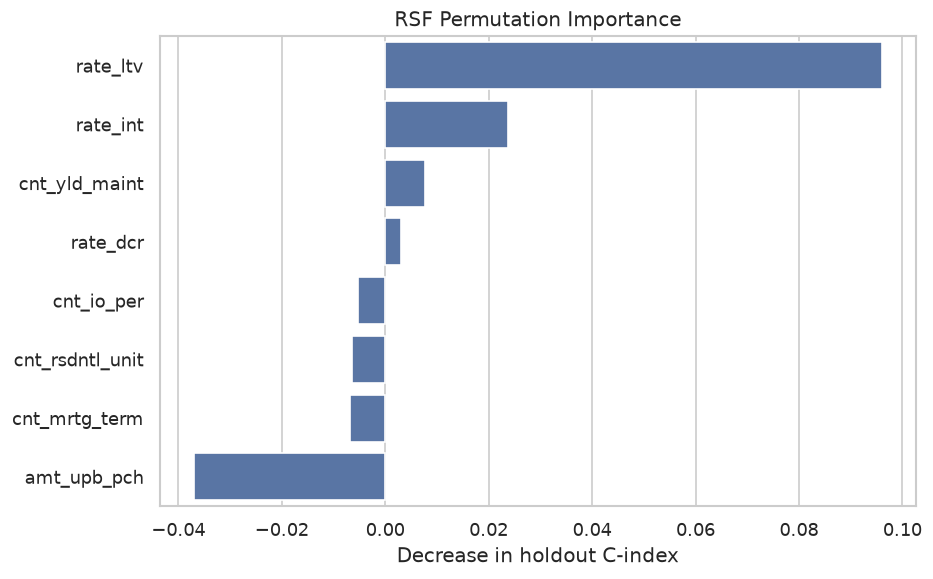

In [23]:
importance = permutation_importance(
    rsf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_table = pd.DataFrame({
    "feature": RSF_FEATURES,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_table)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_table, x="importance_mean", y="feature", ax=ax)
ax.set(
    title="RSF Permutation Importance",
    xlabel="Decrease in holdout C-index",
    ylabel="",
)
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / "04_rsf_permutation_importance.png", dpi=160)
plt.show()

### Optional SHAP explanation of the RSF risk score

SHAP values here explain the RSF's relative risk score, not an absolute
competing-risk default probability. Limit the sample to keep runtime modest.

In [24]:
RUN_SHAP = False

if RUN_SHAP:
    import shap

    background = X_train.sample(min(100, len(X_train)), random_state=RANDOM_STATE)
    explained = X_test.sample(min(100, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.Explainer(rsf.predict, background, algorithm="permutation")
    shap_values = explainer(explained)
    shap.plots.bar(shap_values, max_display=len(RSF_FEATURES))

## Stage 11 - Cause-specific calibration by predicted-risk group

This compares RSF cause-specific failure predictions with `1 - KM` while
censoring payoffs. It does not calibrate absolute competing-risk default CIF.
With approximately 13 defaults in the holdout, use three groups only.

,risk_group,loans,defaults,mean_predicted_failure,observed_one_minus_km
0,Low,1232,2,0.0015,0.0027
1,Medium,1231,3,0.0028,0.0012
2,High,1232,8,0.0058,0.0059


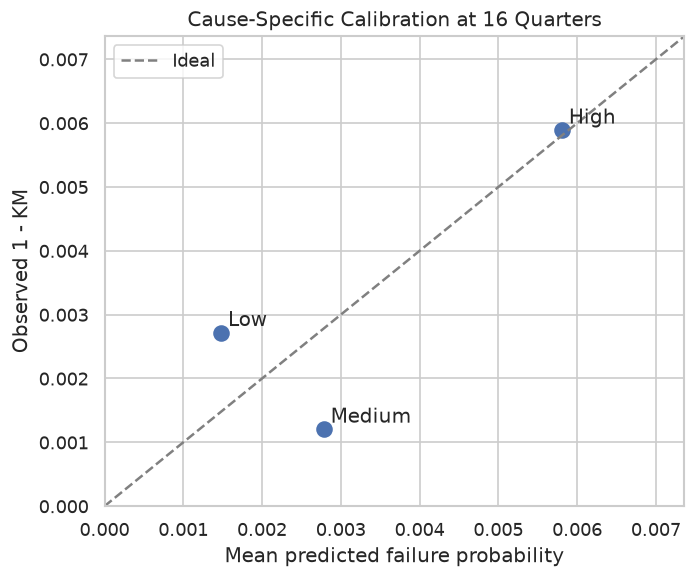

In [25]:
CALIBRATION_HORIZON = 16
test_survival_functions = rsf.predict_survival_function(X_test)
predicted_failure = np.array([
    1 - function(CALIBRATION_HORIZON)
    for function in test_survival_functions
])

calibration = rsf_data.iloc[test_idx][
    ["loan_id", "duration_quarters", "default_event"]
].copy()
calibration["predicted_failure"] = predicted_failure
calibration["risk_group"] = pd.qcut(
    calibration["predicted_failure"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

calibration_rows = []
for risk_group, subset in calibration.groupby("risk_group", observed=True):
    fitter = KaplanMeierFitter()
    fitter.fit(subset["duration_quarters"], subset["default_event"])
    calibration_rows.append({
        "risk_group": risk_group,
        "loans": len(subset),
        "defaults": int(subset["default_event"].sum()),
        "mean_predicted_failure": subset["predicted_failure"].mean(),
        "observed_one_minus_km": 1 - float(fitter.predict(CALIBRATION_HORIZON)),
    })

calibration_table = pd.DataFrame(calibration_rows)
display(calibration_table)

fig, ax = plt.subplots(figsize=(6, 5))
axis_max = 1.25 * max(
    calibration_table["mean_predicted_failure"].max(),
    calibration_table["observed_one_minus_km"].max(),
)
axis_max = max(axis_max, 0.001)
ax.plot([0, axis_max], [0, axis_max], "--", color="grey", label="Ideal")
ax.scatter(
    calibration_table["mean_predicted_failure"],
    calibration_table["observed_one_minus_km"],
    s=80,
)
for _, row in calibration_table.iterrows():
    ax.annotate(
        str(row["risk_group"]),
        (row["mean_predicted_failure"], row["observed_one_minus_km"]),
        xytext=(4, 4),
        textcoords="offset points",
    )
ax.set(
    title=f"Cause-Specific Calibration at {CALIBRATION_HORIZON} Quarters",
    xlabel="Mean predicted failure probability",
    ylabel="Observed 1 - KM",
    xlim=(0, axis_max),
    ylim=(0, axis_max),
)
ax.legend()
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUT_DIR / "05_rsf_calibration.png", dpi=160)
plt.show()

## Stage 12 - Chronological holdout feasibility check

Later vintages have shorter follow-up. This audit searches for a vintage cutoff
with at least 30 training defaults and 10 testing defaults. If no such cutoff
exists, a reliable future-vintage performance estimate is not available.

In [26]:
chronological_candidates = []
for cutoff_year in sorted(analysis["vintage_year"].dropna().unique())[:-1]:
    train_mask = analysis["vintage_year"].le(cutoff_year)
    test_mask = analysis["vintage_year"].gt(cutoff_year)
    chronological_candidates.append({
        "cutoff_year": int(cutoff_year),
        "train_loans": int(train_mask.sum()),
        "test_loans": int(test_mask.sum()),
        "train_defaults": int(analysis.loc[train_mask, "default_event"].sum()),
        "test_defaults": int(analysis.loc[test_mask, "default_event"].sum()),
        "test_median_followup": analysis.loc[test_mask, "duration_quarters"].median(),
    })

chronological_audit = pd.DataFrame(chronological_candidates)
display(chronological_audit)

eligible_cutoffs = chronological_audit.query(
    "train_defaults >= 30 and test_defaults >= 10"
)
if eligible_cutoffs.empty:
    print(
        "No chronological split has enough defaults on both sides. Report this "
        "as a validation limitation and do not claim out-of-time validation."
    )
else:
    selected_cutoff = eligible_cutoffs.iloc[-1]
    print("Feasible chronological cutoff:")
    display(selected_cutoff.to_frame("value"))

No chronological split has enough defaults on both sides. Report this as a validation limitation and do not claim out-of-time validation.


,cutoff_year,train_loans,test_loans,train_defaults,test_defaults,test_median_followup
0,2014,2,14776,0,51,15.0000
1,2015,1008,13770,4,47,14.0000
2,2016,2623,12155,10,41,13.0000
3,2017,5287,9491,26,25,12.0000
4,2018,8042,6736,42,9,9.0000
5,2019,10071,4707,51,0,7.0000
6,2020,11780,2998,51,0,6.0000
7,2021,13736,1042,51,0,3.0000


## Stage 13 - Geographic coverage and bias limitations

The dataset contains geography but no verified protected-class attributes.
Therefore, this is a coverage audit, not a demographic fairness assessment.

In [27]:
geographic_audit = group_event_summary(analysis, "census_region")
geographic_audit["share_of_loans"] = geographic_audit["loans"] / geographic_audit["loans"].sum()
display(geographic_audit)

print(
    "Fairness limitation: protected attributes are unavailable. Do not infer "
    "demographic fairness from state or regional performance."
)

Fairness limitation: protected attributes are unavailable. Do not infer demographic fairness from state or regional performance.


,census_region,loans,defaults,paid_off,median_followup,defaults_per_1000,share_of_loans
0,Midwest,2465,11,642,16.0000,4.4625,0.1668
1,Northeast,4006,27,1356,17.0000,6.7399,0.2711
2,South,3851,12,1592,13.0000,3.1161,0.2606
3,West,4456,1,1648,13.0000,0.2244,0.3015


## Stage 14 - Save core analysis outputs

In [28]:
event_diagnostics.to_csv(ANALYSIS_OUTPUT_DIR / "event_diagnostics.csv", index=False)
km_horizons.to_csv(ANALYSIS_OUTPUT_DIR / "km_horizons.csv", index=False)
cif_horizons.to_csv(ANALYSIS_OUTPUT_DIR / "competing_risk_cif_horizons.csv", index=False)
logrank_results.to_csv(ANALYSIS_OUTPUT_DIR / "logrank_results.csv", index=False)
importance_table.to_csv(ANALYSIS_OUTPUT_DIR / "rsf_permutation_importance.csv", index=False)
calibration_table.to_csv(ANALYSIS_OUTPUT_DIR / "rsf_calibration.csv", index=False)
chronological_audit.to_csv(ANALYSIS_OUTPUT_DIR / "chronological_split_audit.csv", index=False)
geographic_audit.to_csv(ANALYSIS_OUTPUT_DIR / "geographic_coverage_audit.csv", index=False)

print(f"Analysis outputs saved to: {ANALYSIS_OUTPUT_DIR.resolve()}")

Analysis outputs saved to: analysis_outputs


## What is intentionally excluded

- PCA and clustering: they do not answer the time-to-default question and can
  obscure already-sparse default signals.
- Unpenalized high-dimensional Cox regression: 51 defaults are insufficient.
- Fine-grained deal/state hazard models: many groups contain zero defaults.
- Deep learning: the event count, not the row count, determines usable signal.
- Claims of calibrated absolute loan default probability from Cox or RSF:
  competing payoff risk requires a dedicated competing-risk prediction model.

## Consolidated results

In [29]:
final_results = pd.Series({
    "Loans": len(analysis),
    "Observed defaults": int(analysis["default_event"].sum()),
    "Observed payoffs": int(analysis["prepay_event"].sum()),
    "32-quarter default CIF": step_value_at(default_cif, 32),
    "32-quarter payoff CIF": step_value_at(prepay_cif, 32),
    "RSF holdout C-index": c_index,
    "RSF mean dynamic AUC": mean_auc if "mean_auc" in globals() else np.nan,
    "RSF integrated Brier score": ibs if "ibs" in globals() else np.nan,
    "RSF five-fold mean C-index": (
        cv_results["c_index"].mean() if "cv_results" in globals() else np.nan
    ),
})
display(final_results.to_frame("Value"))

,Value
Loans,"14,778.0000"
Observed defaults,51.0000
Observed payoffs,"5,238.0000"
32-quarter default CIF,0.0066
32-quarter payoff CIF,0.8107
RSF holdout C-index,0.6370
RSF mean dynamic AUC,0.6479
RSF integrated Brier score,0.0053
RSF five-fold mean C-index,0.7670


## Final interpretation

The portfolio exhibited strong credit performance. Estimated eight-year
default cumulative incidence was approximately **0.66%**, while payoff
cumulative incidence reached approximately **81%**. This gap demonstrates why
prepayment must be modeled as a competing event rather than ordinary censoring.

Higher LTV, weaker DCR, and prior delinquency were associated with greater
credit risk. In the penalized time-varying Cox model, prior delinquency was the
clearest predictor, while the baseline continuous predictors were heavily
shrunk. The Random Survival Forest provided moderate holdout discrimination,
but performance weakened at longer horizons.

### What the analysis supports

- Portfolio-level default and payoff incidence measurement.
- Interpretable comparison of broad underwriting risk groups.
- Exploratory relative-risk ranking of currently active loans.
- Identification of prior delinquency as a strong monitoring signal.

### What the analysis does not support

- Production-grade loan-level probabilities of default.
- Causal conclusions about geography or underwriting characteristics.
- Reliable future-vintage validation: no chronological split contains enough
  defaults on both sides.
- Demographic fairness conclusions: protected-class attributes are unavailable.

### Recommended use

Use the output as an **early-warning and portfolio-monitoring framework**. Any
production implementation should be retrained as additional defaults emerge,
validated on later vintages, and supplemented with updated property performance
and macroeconomic variables.